# Building Energy Performance Prediction: Supporting Sustainable Urbanization
### A Research Reproduction Study

**Based on:** Tsanas, A. & Xifara, A. (2012) - Energy and Buildings, Vol. 49

**Status:**
- Phase 1: Linear Regression + Ridge Regression 
- Phase 2: Random Forest (Future Work)

---

## Problem Statement

Buildings are responsible for approximately **40% of global energy consumption** and **36% of CO2 emissions**, with heating and cooling accounting for the majority of this usage. As urbanization accelerates — particularly in developing nations where 75% of buildings expected to exist by 2030 have yet to be constructed — there is a critical need to design energy-efficient buildings from the outset.

Traditional building energy assessment occurs post-construction, when design changes are costly or impossible. This project addresses the question:

> **Can we accurately predict a building's heating and cooling energy requirements based solely on its design parameters before construction begins?**

### Research Background

This project reproduces the methodology of **Tsanas & Xifara (2012)**, which studied building energy performance prediction using machine learning. The paper explicitly noted that:

> *"Linear modelling techniques are NOT appropriate for this data, since the scatter and density plots do not follow a Gaussian distribution"*

The paper demonstrated that Random Forests achieve significantly better performance than linear regression — a finding we aim to independently verify.

### Project Objectives

Given the research findings above, this project aims to:

1. Independently verify research findings through Exploratory Data Analysis (EDA)
2. Implement linear regression as a baseline model
3. Extend with Ridge Regression (L2) to address multicollinearity identified in EDA
4. Confirm the paper's finding that linear models show mediocre performance on this dataset
5. Propose Random Forest implementation as future work to verify the reported 3x performance improvement

---

## Dataset Overview

### Source

| Field | Details |
|-------|---------|
| **Dataset** | Energy Efficiency Dataset |
| **Repository** | UCI Machine Learning Repository |
| **Authors** | Tsanas, A. & Xifara, A. |
| **Publication** | "Accurate quantitative estimation of energy performance of residential buildings using statistical machine learning tools" |
| **Journal** | Energy and Buildings, Vol. 49, pp. 560-567 (2012) |
| **DOI** | 10.1016/j.enbuild.2012.03.003 |
| **Total Samples** | 768 simulated buildings |
| **Input Features** | 8 building design parameters |
| **Target Variables** | 2 energy load measurements |
| **Missing Values** | None |

### About the Dataset

This dataset was created using **Ecotect**, a professional building energy simulation software, to model 768 different residential building designs. The simulations represent buildings located in **Athens, Greece**, with a Mediterranean climate characterized by hot summers and mild winters — a climate comparable to many hot urban regions globally, including parts of India.

**Key Characteristics:**
- All buildings share the same **volume (771.75 m³)** to ensure controlled comparison — any differences in energy loads are purely due to design choices
- Buildings vary in **shape, window coverage, orientation**, and other architectural parameters
- Constructed using **modern building materials** with low heat loss coefficients (U-values)
- Data represents **high-fidelity simulations** validated against real-world building performance by the original authors

The controlled experimental design makes this an ideal dataset for studying how individual architectural decisions impact energy performance.

---

### Features Description

#### Input Variables (X1–X8): Building Design Parameters

| Feature | Name | Description | Unit | Range/Values |
|---------|------|-------------|------|--------------|
| X1 | **Relative Compactness (RC)** | Ratio measuring how compact the building shape is. A cube (compact) has a higher value than a long rectangle (spread out). More compact buildings have less surface area relative to volume, meaning fewer surfaces for heat to escape through. | Dimensionless | 0.62 – 0.98 |
| X2 | **Surface Area (SA)** | Total exterior surface area of the building including walls, roof, and floor. Larger surface area provides more area for heat exchange with the environment. | m² | 514 – 808 |
| X3 | **Wall Area (WA)** | Total area of exterior walls only (excluding roof and floor). Walls are the primary surfaces for windows and insulation. | m² | 245 – 416 |
| X4 | **Roof Area (RA)** | Total roof surface area. Roofs receive direct solar radiation in summer and lose heat upward in winter. | m² | 110 – 220 |
| X5 | **Overall Height (OH)** | Vertical height of the building. Only two values exist: 3.5m (single-story) and 7.0m (two-story). | meters | 3.5 or 7.0 |
| X6 | **Orientation (O)** | Cardinal direction the building faces. Encoded as integers where 2=North, 3=East, 4=South, 5=West. **Note: This is a nominal categorical variable — the numbers are labels, not quantities.** | Categorical | 2, 3, 4, 5 |
| X7 | **Glazing Area (GA)** | Percentage of floor area covered by windows. More windows create more thermal exchange points — losing heat in winter and gaining heat in summer. | % of floor area | 0, 10, 25, 40 |
| X8 | **Glazing Area Distribution (GAD)** | How windows are distributed across the building's four faces. **Note: This is a nominal categorical variable — values represent patterns, not quantities.** | Categorical | 0–5 (see below) |

**Glazing Area Distribution (GAD) — Value Meanings:**

| Value | Meaning | Description |
|-------|---------|-------------|
| 0 | No glazing | No windows at all |
| 1 | Uniform | 25% on each side (N, S, E, W) |
| 2 | North-heavy | 55% on North, 15% on each other side |
| 3 | East-heavy | 55% on East, 15% on each other side |
| 4 | South-heavy | 55% on South, 15% on each other side |
| 5 | West-heavy | 55% on West, 15% on each other side |

**Important note on RC:** While the raw correlation between RC and heating_load is positive (+0.62) due to its relationship with building height, the model coefficient is negative. This is physically correct — all else being equal, a more compact building requires less heating because it has less surface area for heat to escape through. The positive raw correlation is explained by multicollinearity (taller buildings tend to also be more compact in this dataset).

---

#### Target Variables (Y1–Y2): Energy Requirements

| Target | Name | Description | Unit | Range |
|--------|------|-------------|------|-------|
| Y1 | **Heating Load (HL)** | Energy required to maintain comfortable indoor temperature (~20°C) during cold weather. Lower values indicate more energy-efficient buildings. | kWh | 6.01 – 43.10 |
| Y2 | **Cooling Load (CL)** | Energy required to maintain comfortable indoor temperature (~24°C) during hot weather. Lower values indicate more energy-efficient buildings. | kWh | 10.90 – 48.03 |

**Project focus:** This project predicts **Heating Load (Y1)** as the primary target. Cooling Load (Y2) is retained for EDA comparison but not modeled in Phase 1.

---

### Key Insights from Prior Research

Studies analyzing this dataset — including the original paper and subsequent research using fuzzy logic, neural networks, and support vector machines — have revealed the following key findings that directly inform our approach:

| Finding | Details |
|---------|---------|
| **GA most important (non-linear)** | Glazing Area identified as strongest predictor using Random Forests and non-linear methods |
| **RC second most important** | Relative Compactness is the second most influential feature |
| **Orientation negligible** | Orientation shows ~zero correlation with both heating and cooling loads — confirmed across multiple studies |
| **Multicollinearity confirmed** | RC ↔ SA: -0.99, OH ↔ RA: -0.97 — structural features are mathematically linked |
| **Linear regression mediocre** | RMSE ~3.14 kWh for heating load (paper's IRLS result) |
| **Random Forest superior** | RMSE ~1.01 kWh — approximately 3x better than linear regression |
| **Non-linear relationships** | Paper explicitly states linear models are NOT appropriate for this data |
| **HL and CL highly correlated** | Correlation ~0.98 — features that drive heating also drive cooling |

These benchmarks provide clear targets for our implementation and motivate the future Random Forest phase of this project.

---

### Relevance to India's Energy Challenge

While this dataset simulates buildings in Athens, Greece, the methodology and findings are directly applicable to India's growing energy challenge:

- Buildings account for **33% of India's electricity consumption**
- India will add **300 million urban residents** by 2040, most in buildings yet to be constructed
- Air conditioning demand projected to grow **15x by 2050**, making cooling load prediction critical
- **75% of India's 2030 building stock** has not yet been built — making pre-construction energy modeling essential

This project demonstrates ML techniques directly applicable to India's **Energy Conservation Building Code (ECBC)**, **Smart Cities Mission**, and **net-zero emissions target (2070)**.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# The first few rows of the data 
data = pd.read_csv(r'C:\Users\user\OneDrive\Desktop\MAIN PORTFOLIO\BUILDING ENERGY\Linear_Regression\data_energy.csv')
data.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


### Renaming Columns for Clarity

The dataset uses generic column names (X1-X8 for features, Y1-Y2 for targets). 
We'll rename them to descriptive names based on the dataset documentation.

In [6]:
new_column_names = ['relative_compactness','surface_area','wall_area','roof_area','overall_height','orientation','glazing_area',
                    'glazing_area_distribution','heating_load','cooling_load']

data.columns = new_column_names

In [7]:
data.head(10)

,relative_compactness,surface_area,wall_area,roof_area,overall_height,orientation,glazing_area,glazing_area_distribution,heating_load,cooling_load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28
5,0.90,563.5,318.5,122.50,7.0,3,0.0,0,21.46,25.38
6,0.90,563.5,318.5,122.50,7.0,4,0.0,0,20.71,25.16
7,0.90,563.5,318.5,122.50,7.0,5,0.0,0,19.68,29.60
8,0.86,588.0,294.0,147.00,7.0,2,0.0,0,19.50,27.30
9,0.86,588.0,294.0,147.00,7.0,3,0.0,0,19.95,21.97


In [8]:
# Information of the data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   relative_compactness       768 non-null    float64
 1   surface_area               768 non-null    float64
 2   wall_area                  768 non-null    float64
 3   roof_area                  768 non-null    float64
 4   overall_height             768 non-null    float64
 5   orientation                768 non-null    int64  
 6   glazing_area               768 non-null    float64
 7   glazing_area_distribution  768 non-null    int64  
 8   heating_load               768 non-null    float64
 9   cooling_load               768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


In [9]:
# Basic Descriptive statistics--
data.describe()

,relative_compactness,surface_area,wall_area,roof_area,overall_height,orientation,glazing_area,glazing_area_distribution,heating_load,cooling_load
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307201,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090196,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


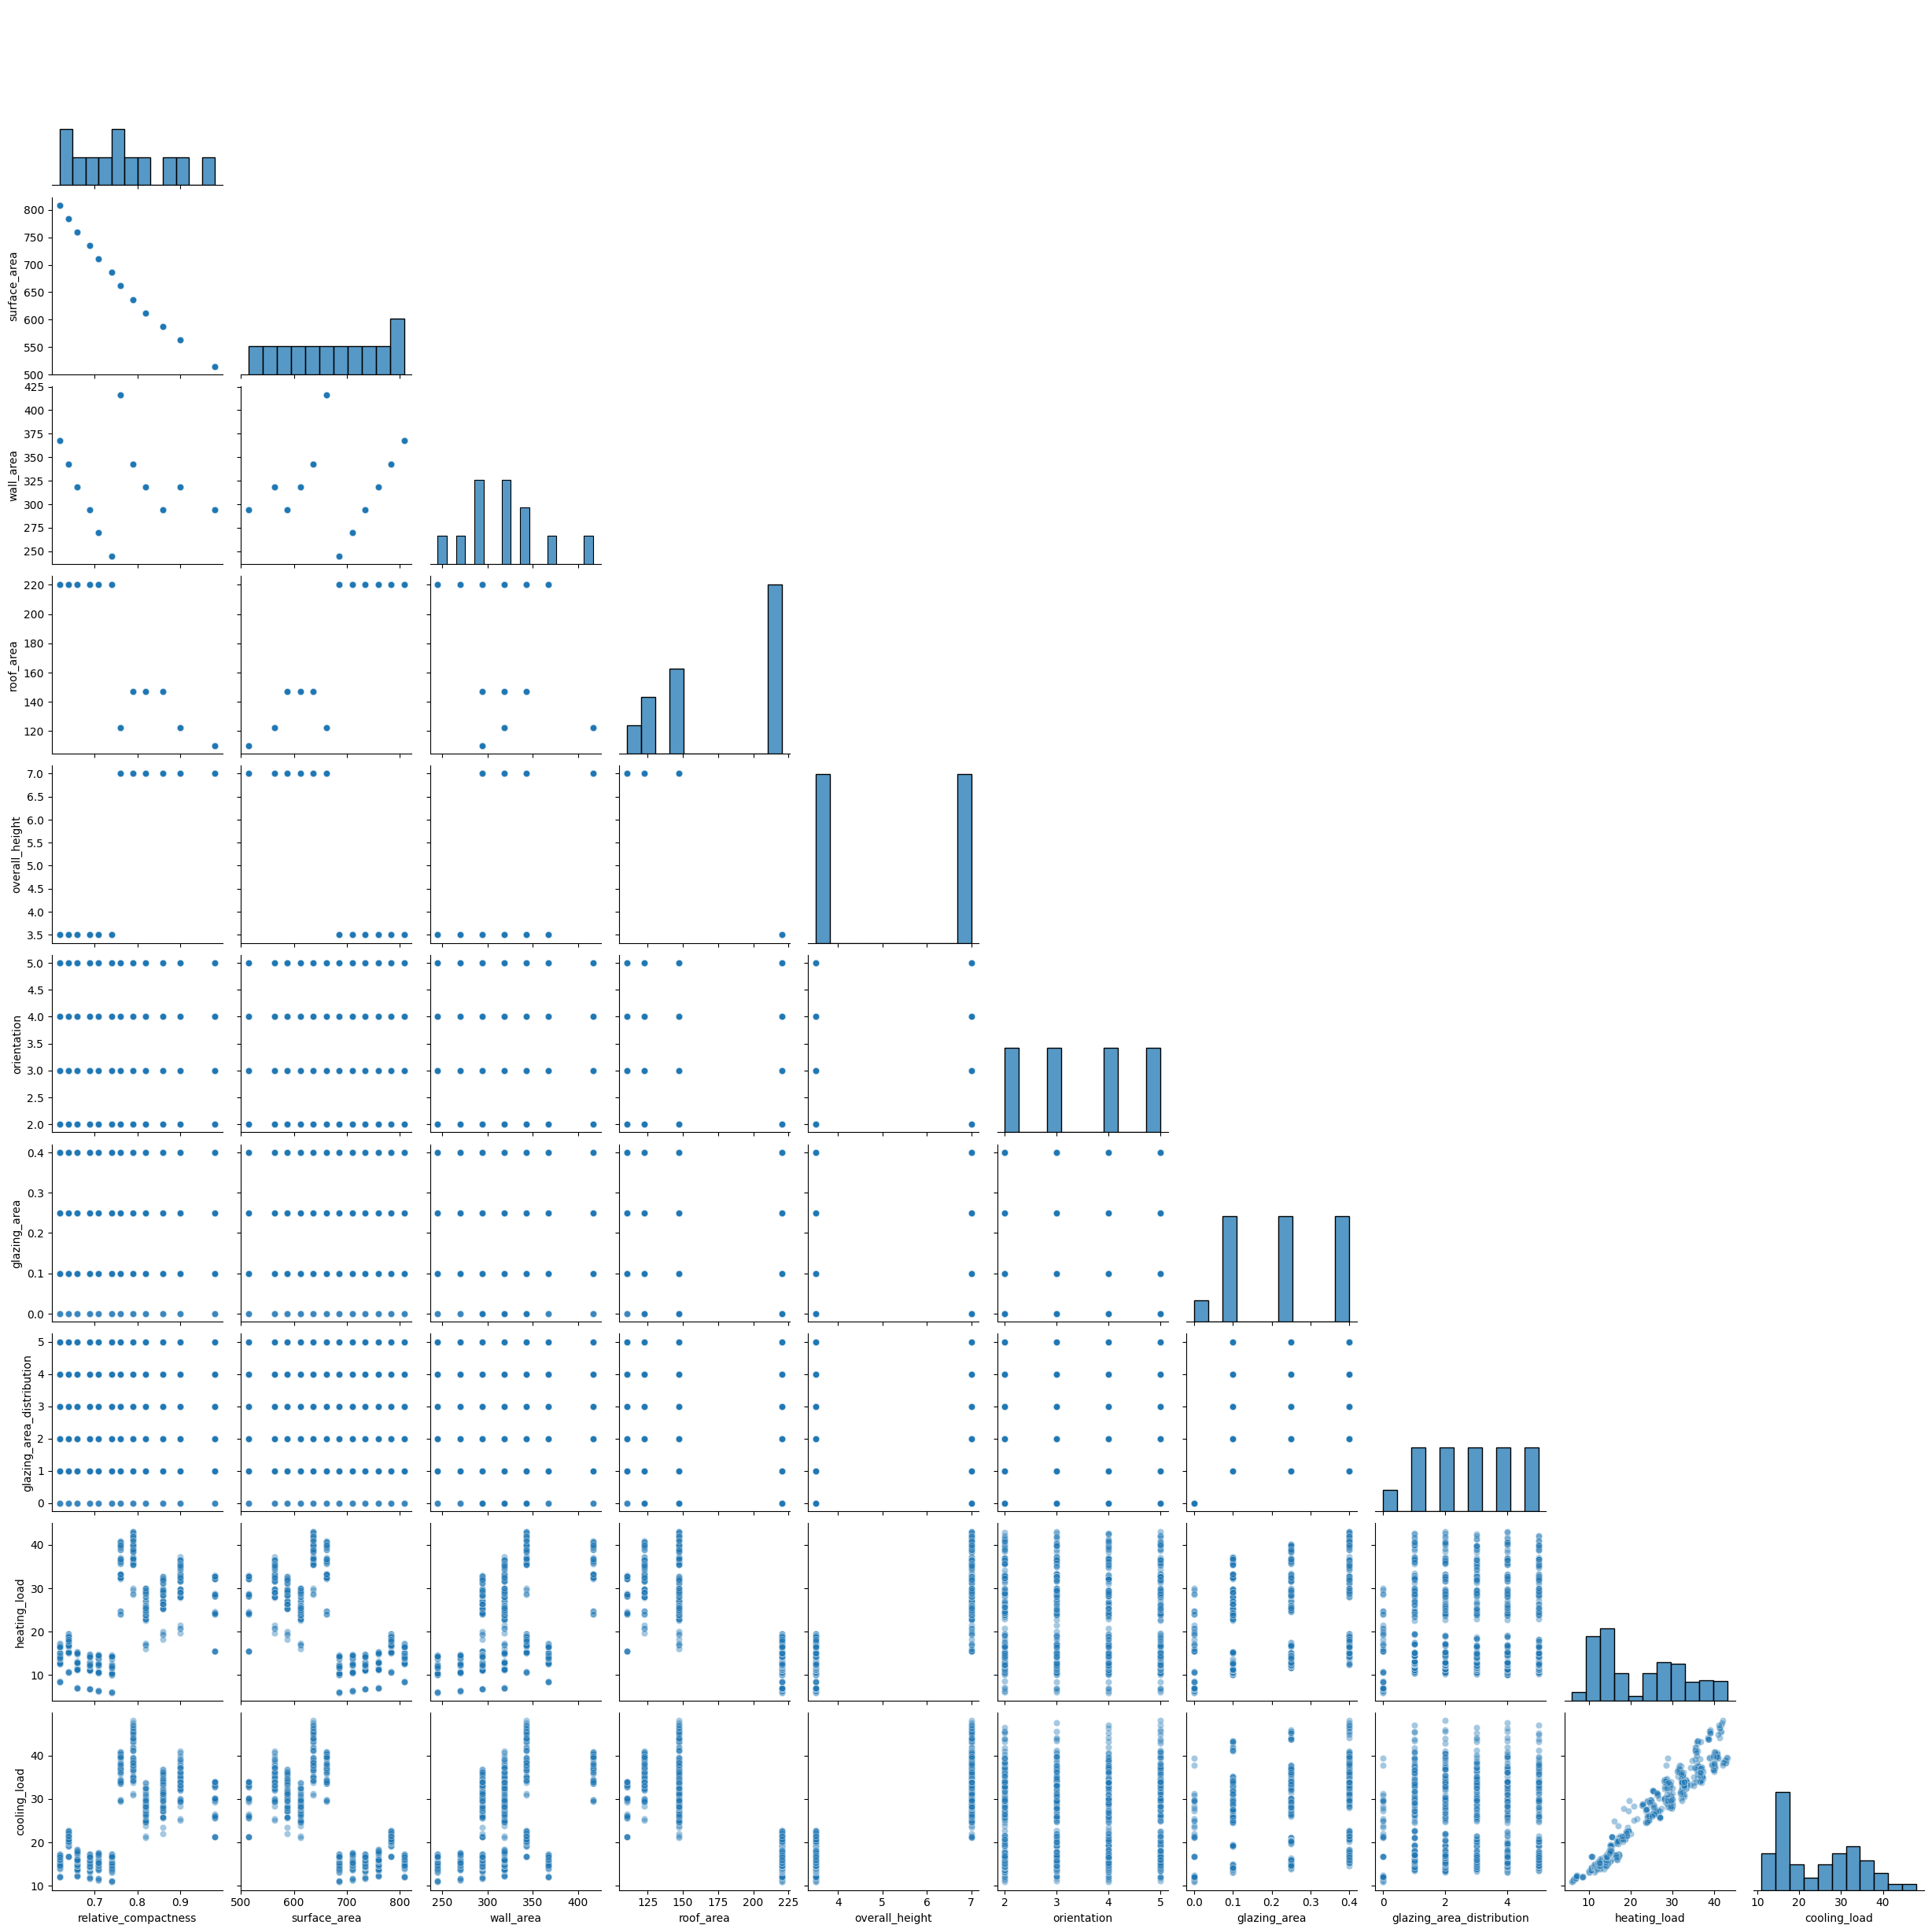

In [10]:
sns.pairplot(data,kind='scatter',plot_kws={'alpha':0.4},corner=True)

In [11]:
# Check for null values--
print(data.isnull().sum())


relative_compactness         0
surface_area                 0
wall_area                    0
roof_area                    0
overall_height               0
orientation                  0
glazing_area                 0
glazing_area_distribution    0
heating_load                 0
cooling_load                 0
dtype: int64


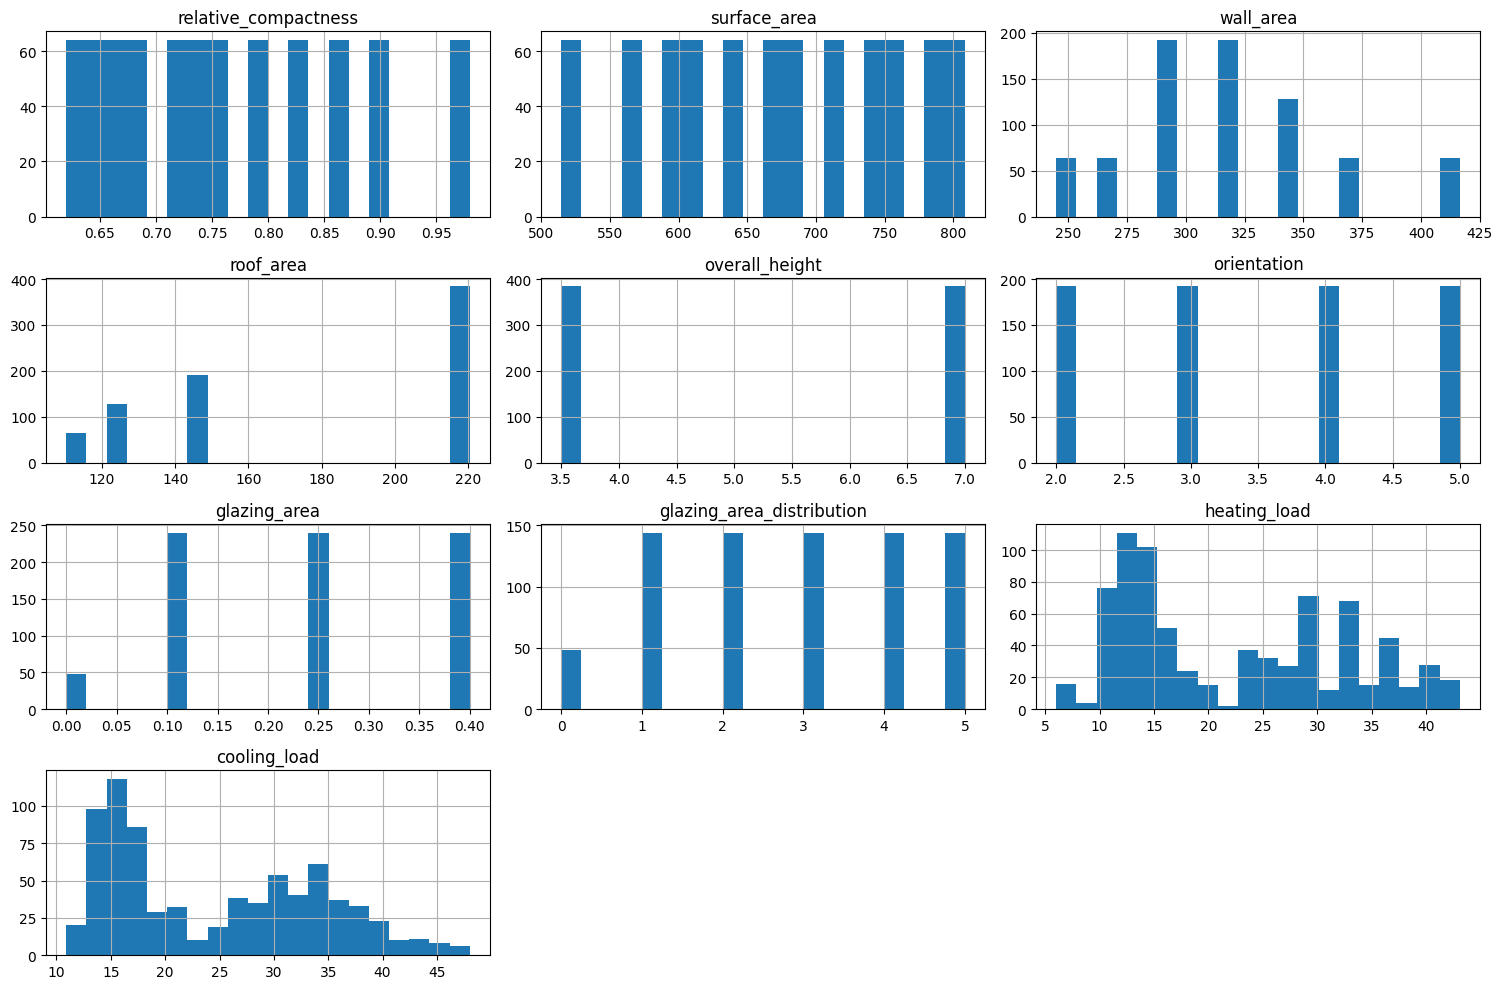

In [12]:
# distribution plots--
data.hist(figsize=(15,10),bins=20)
plt.tight_layout()
plt.show()

### Distribution Analysis

Key observations from feature distributions:

1. **relative_compactness & surface_area:** Uniform distributions 
   confirming balanced sampling across building shapes

2. **overall_height & orientation:** Perfectly balanced categorical 
   features - equal representation of all categories

3. **heating_load (target):** Bimodal distribution suggesting two 
   distinct building groups (likely single vs two-story buildings)

4. **cooling_load:** Right-skewed distribution, different pattern 
   from heating_load despite high correlation

5. **roof_area:** Right-skewed with dominant spike at ~220 m²

6. **glazing_area_distribution:** Low count at 0 (no windows) 
   confirms link with glazing_area

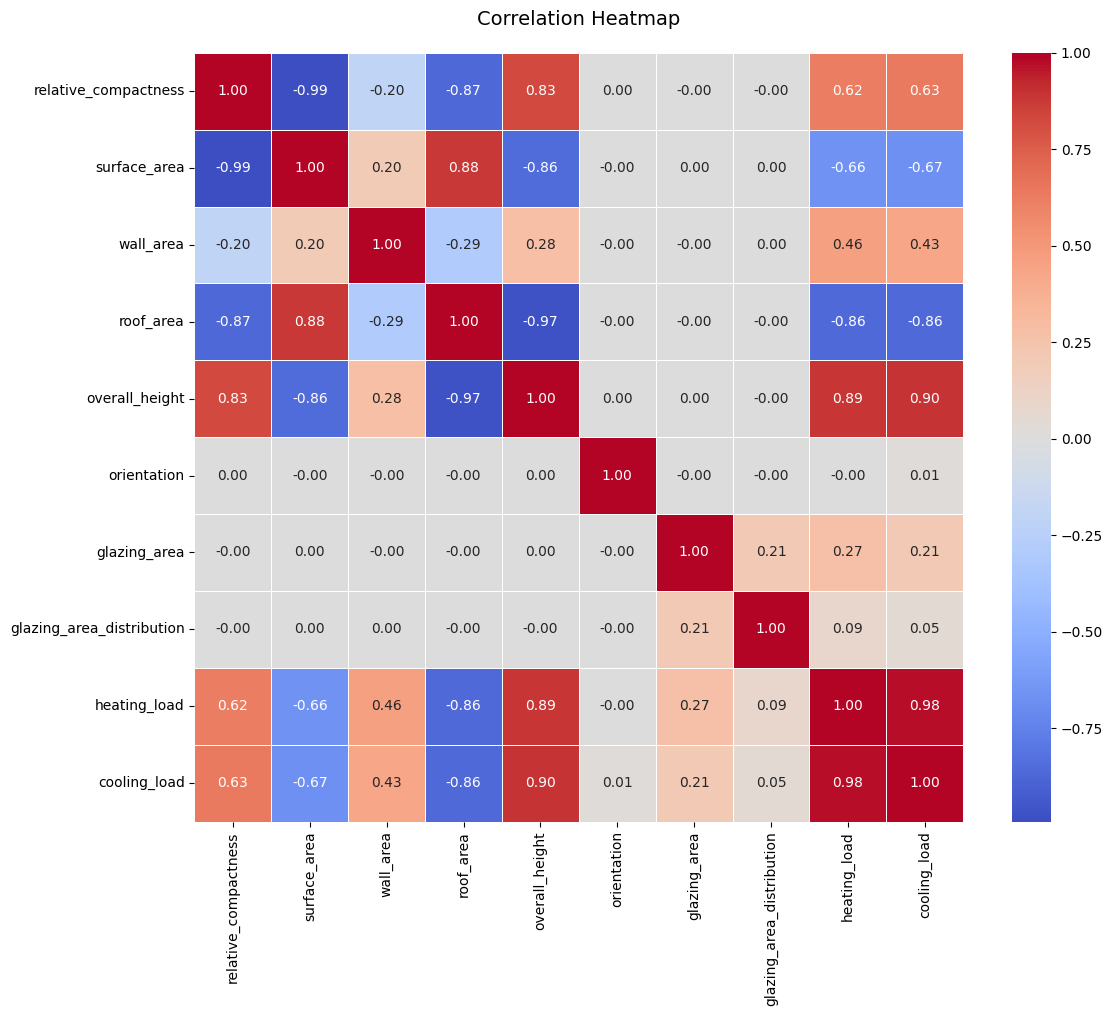

In [13]:
# Correlation Heatmap--

plt.figure(figsize=(12,10))
sns.heatmap(
        data.corr(),
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        center=0 ,
        square=True,
        linewidth=0.5
    )
plt.title('Correlation Heatmap',fontsize=14, pad=20)
plt.tight_layout()
plt.show()

### Correlation Analysis - Key Findings

#### Correlations with Heating Load (Target Variable):

| Feature | Correlation | Interpretation |
|---------|-------------|----------------|
| overall_height | +0.89 | Strongest predictor - taller buildings need more heating |
| roof_area | -0.86 | Larger roofs = single-story = less heating needed |
| surface_area | -0.66 | More surface area = less compact = less height |
| relative_compactness | +0.62 | More compact buildings tend to be taller |
| wall_area | +0.46 | More wall area = more heat escape points |
| glazing_area | +0.27 | More windows = more heat loss |
| glazing_area_distribution | +0.09 | Window placement has minimal impact |
| orientation | -0.00 | Building direction has NO effect on heating! |

#### Critical Finding 1: Multicollinearity
Several features are highly correlated with each other:
- relative_compactness ↔ surface_area: -0.99 (near perfect!)
- overall_height ↔ roof_area: -0.97 (near perfect!)

These features contain redundant information. While we keep all features 
for completeness, this multicollinearity may affect coefficient stability 
in our linear regression model.

#### Critical Finding 2: Orientation Surprise
orientation shows ~0.00 correlation with heating_load, confirming the 
research finding that building direction has minimal impact on energy 
performance compared to structural features. This is counterintuitive 
but consistent with the original Tsanas & Xifara (2012) findings.

#### Critical Finding 3: Target Correlation
heating_load and cooling_load show 0.98 correlation, suggesting that 
buildings inefficient in winter are equally inefficient in summer. 
The same design features drive both energy loads.

#### Implications for Modeling:
- overall_height and glazing_area are the most reliable independent 
  predictors (not redundant with each other)
- Multicollinear features may produce unstable coefficients
- orientation can likely be dropped without affecting model performance
- Linear regression is appropriate given the linear relationships observed

In [14]:
# Splitting Features and Targets--
X = data[['relative_compactness','surface_area','wall_area','roof_area','overall_height','orientation','glazing_area','glazing_area_distribution']]
y = data['heating_load']

In [15]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(X, y,test_size = 0.3,random_state = 42)

In [16]:
"""One Hot Encoding categorical variables--
    1. orientation
    2. glazing_area_distribution
"""
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

numerical_data = ['relative_compactness','surface_area','wall_area','roof_area','overall_height','glazing_area']
categorical_data = ['orientation','glazing_area_distribution']

preprocessor = ColumnTransformer(
            transformers=[
                ('cat', OneHotEncoder(drop= 'first'), categorical_data),
                ('num', 'passthrough',numerical_data)
            ])

preprocessor.fit(X_train)

x_train_encoded = preprocessor.transform(X_train)
x_test_encoded = preprocessor.transform(X_test)

print(f"Training data shape: {x_train_encoded.shape}")
print(f"Test data shape: {x_test_encoded.shape}")

feature_names = preprocessor.get_feature_names_out()
print("New feature names:", feature_names)


Training data shape: (537, 14)
Test data shape: (231, 14)
New feature names: ['cat__orientation_3' 'cat__orientation_4' 'cat__orientation_5'
 'cat__glazing_area_distribution_1' 'cat__glazing_area_distribution_2'
 'cat__glazing_area_distribution_3' 'cat__glazing_area_distribution_4'
 'cat__glazing_area_distribution_5' 'num__relative_compactness'
 'num__surface_area' 'num__wall_area' 'num__roof_area'
 'num__overall_height' 'num__glazing_area']


In [17]:
X_train_df = pd.DataFrame(x_train_encoded, columns=feature_names)
X_test_df = pd.DataFrame(x_test_encoded, columns=feature_names)

print(X_train_df.head())

   cat__orientation_3  cat__orientation_4  cat__orientation_5  \
0                 0.0                 1.0                 0.0   
1                 0.0                 0.0                 1.0   
2                 1.0                 0.0                 0.0   
3                 0.0                 0.0                 1.0   
4                 0.0                 1.0                 0.0   

   cat__glazing_area_distribution_1  cat__glazing_area_distribution_2  \
0                               1.0                               0.0   
1                               0.0                               1.0   
2                               0.0                               0.0   
3                               1.0                               0.0   
4                               0.0                               0.0   

   cat__glazing_area_distribution_3  cat__glazing_area_distribution_4  \
0                               0.0                               0.0   
1                       

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train_df)

X_train_scaled = scaler.transform(X_train_df)
X_test_scaled = scaler.transform(X_test_df)


print(f"Training data shape: {X_train_scaled.shape}")  
print(f"Test data shape: {X_test_scaled.shape}")        
print(f"\nSample of scaled values:\n {X_train_scaled[:2]}")

Training data shape: (537, 14)
Test data shape: (231, 14)

Sample of scaled values:
 [[-0.59957791  1.73420376 -0.57089923  2.21384256 -0.46952587 -0.51335116
  -0.47247711 -0.49008648 -1.34062531  1.52415292  1.12126375  0.94613767
  -0.97244649  0.10492788]
 [-0.59957791 -0.57663351  1.75162262 -0.4517033   2.12980808 -0.51335116
  -0.47247711 -0.49008648 -1.1495902   1.24471621  0.55906148  0.94613767
  -0.97244649 -1.01453443]]


In [19]:
# Preparing the model--
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

In [20]:
# Fit the model--
lr.fit(X_train_scaled,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
# Obtaining the coefficients--
lr.coef_

array([-6.47599026e-02, -4.54754872e-03, -7.82360400e-02,  1.69146896e+00,
        1.77018912e+00,  1.84658949e+00,  1.57918280e+00,  1.73015349e+00,
       -6.91135662e+00, -3.82726634e+00,  7.12127316e-01, -4.09168933e+00,
        7.24476867e+00,  2.23831553e+00])

In [22]:
coef_df = pd.DataFrame(lr.coef_,X_train_df.columns,columns=['lr coef'])
coef_df

,lr coef
cat__orientation_3,-0.064760
cat__orientation_4,-0.004548
cat__orientation_5,-0.078236
cat__glazing_area_distribution_1,1.691469
cat__glazing_area_distribution_2,1.770189
cat__glazing_area_distribution_3,1.846589
cat__glazing_area_distribution_4,1.579183
cat__glazing_area_distribution_5,1.730153
num__relative_compactness,-6.911357
num__surface_area,-3.827266


In [23]:
predictions = lr.predict(X_test_scaled)
predictions

array([18.59930488, 14.75482168, 31.03152039, 35.20404222, 14.83896388,
       28.89178265, 25.92949938, 28.58204701, 17.91172417, 28.44386447,
       17.76640735, 34.55296937, 27.8055588 ,  8.69792363, 17.78126333,
       37.57151648, 37.2015933 , 10.91388168, 15.39061503, 34.40613161,
       34.35980314, 35.63476353, 12.23860317, 30.20313113, 12.62300583,
       30.05629337, 33.36468293, 34.17809823, 15.4060143 , 15.9118901 ,
        9.06784681, 11.39185177, 15.29556464, 31.81770518, 30.44163888,
       28.57153836, 30.90605196, 30.61283515, 33.50101204, 10.27606207,
       28.34845294, 11.06071944,  4.09690072, 32.20659388,  4.61176423,
        3.92570446,  5.88824556, 10.13973295, 29.66449592, 30.60102049,
       33.30844645, 14.62436084, 14.66574135, 32.52713608, 12.48011483,
       12.46958312, 11.42671892, 31.67673569, 39.56438911, 37.51528   ,
       15.80821358, 18.43245595, 14.44265593, 29.17102583, 28.17725668,
       30.02142622, 30.19262248, 12.24911181, 12.94957947, 11.37

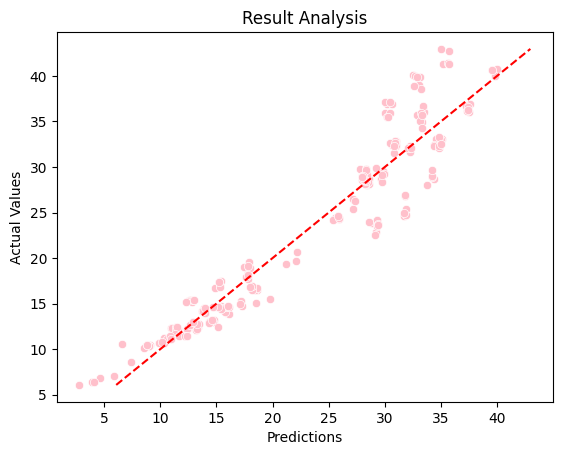

In [24]:
# Undersatnding the pattern of predictions--
sns.scatterplot(x=predictions,y=y_test,c='pink')
# Add perfect prediction line
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', label='Perfect Prediction')
plt.xlabel('Predictions')
plt.ylabel('Actual Values')
plt.title('Result Analysis')
plt.show()

In [25]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
import math

print(f"The mean squared errors of the model is: {mean_squared_error(y_test,predictions):.2f}")
print(f"The r squared of the model is: {r2_score(y_test,predictions):.2f}")
print(f"The Root Mean Squared Error of the model is: {math.sqrt(mean_squared_error(y_test,predictions)):.2f} kWh")
print(f"The mean absolute error of the model is: {mean_absolute_error(y_test,predictions):.2f} kWh")

The mean squared errors of the model is: 8.34
The r squared of the model is: 0.92
The Root Mean Squared Error of the model is: 2.89 kWh
The mean absolute error of the model is: 2.10 kWh


### Note on Methodology

The original paper employed IRLS (Iteratively Reweighted 
Least Squares) for linear regression. This project uses 
sklearn's OLS (Ordinary Least Squares) implementation with 
StandardScaler preprocessing.

Despite methodological differences, our results (RMSE=2.89) 
are comparable to the paper's (RMSE~3.14), and all key 
research findings are independently verified. The goal of 
this project is research reproduction through finding 
verification, not exact algorithmic replication.

In [26]:
# Performing Cross Validation--
from sklearn.linear_model import RidgeCV

alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]

ridge_model = RidgeCV(alphas=alphas, cv=5)

ridge_model.fit(X_train_scaled, y_train)

print(f"The best alpha value is: {ridge_model.alpha_}")

y_pred_ridge = ridge_model.predict(X_test_scaled)

print(f"R SQUARED: {r2_score(y_test,y_pred_ridge):.4f}")
print(f"The Mean Squared Error :{mean_squared_error(y_test,y_pred_ridge):.4f}")
print(f"RMSE : {math.sqrt(mean_squared_error(y_test,y_pred_ridge)):.4f} kWh")
print(f"Mean Absolute Error: {mean_absolute_error(y_test,y_pred_ridge):.4f} kWh")

The best alpha value is: 0.1
R SQUARED: 0.9178
The Mean Squared Error :8.3370
RMSE : 2.8874 kWh
Mean Absolute Error: 2.1017 kWh


Ridge Regression with optimal alpha=0.1 (selected via 
5-fold cross validation) produced virtually identical 
predictive performance to plain linear regression 
(RMSE: 2.8874 vs 2.8876 kWh, R²: 0.9178 vs 0.9178).

This suggests that while multicollinearity exists in the 
structural features (RC↔SA: -0.99, OH↔RA: -0.97), it does 
not severely impact OLS prediction accuracy for this dataset. 
Ridge's primary benefit here is coefficient stability rather 
than predictive improvement.

The minimal regularization needed (α=0.1) further confirms 
that the fundamental limitation of this model is not 
multicollinearity but rather the non-linear relationships 
in the data - as explicitly warned by Tsanas & Xifara (2012).

In [27]:
coef_df['ridge coef'] = ridge_model.coef_
coef_df

,lr coef,ridge coef
cat__orientation_3,-0.064760,-0.064989
cat__orientation_4,-0.004548,-0.004379
cat__orientation_5,-0.078236,-0.077717
cat__glazing_area_distribution_1,1.691469,1.685699
cat__glazing_area_distribution_2,1.770189,1.764906
cat__glazing_area_distribution_3,1.846589,1.840769
cat__glazing_area_distribution_4,1.579183,1.573604
cat__glazing_area_distribution_5,1.730153,1.724887
num__relative_compactness,-6.911357,-6.734715
num__surface_area,-3.827266,-3.706652


### Coefficient Comparison: Linear Regression vs Ridge

Ridge Regression with α=0.1 produced subtle but meaningful 
coefficient changes:

**Most shrinkage (multicollinear structural features):**
- relative_compactness: -6.911 → -6.735 (shrunk by 0.177)
- surface_area: -3.827 → -3.707 (shrunk by 0.121)  
- roof_area: -4.092 → -3.988 (shrunk by 0.104)

**Least shrinkage (independent features):**
- glazing_area: barely changed (0.002)
- orientation: barely changed (<0.001)

**Key insight:** Ridge correctly identified and shrunk the 
multicollinear structural features most, while leaving 
independent features (glazing_area, orientation) largely 
unchanged. This confirms Ridge's L2 penalty effectively 
targets correlated coefficients.

**However:** The small alpha (0.1) and minimal metric 
improvement suggest multicollinearity is not the primary 
limitation of this model. The fundamental challenge remains 
the non-linear relationships in the data, motivating our 
Random Forest future work.

# Conclusions & Future Work

## Summary of Findings

This project set out to independently reproduce and verify the key findings of Tsanas & Xifara (2012) using a modern, industry-standard machine learning implementation. Across two model phases — Ordinary Least Squares (OLS) Linear Regression and Ridge Regression (L2) — our results show strong alignment with the original research while also revealing meaningful methodological nuances.

---

## Methodological Differences

The original paper employed **IRLS (Iteratively Reweighted Least Squares)**, a weighted linear regression method designed to handle non-Gaussian distributions. This project instead used **sklearn's OLS (Ordinary Least Squares)** implementation with StandardScaler preprocessing and proper one-hot encoding of categorical features — a more industry-standard approach.

Despite this methodological difference, both implementations produced comparable results:

| Metric | Paper (IRLS) | Our OLS Baseline | Our Ridge (α=0.1) |
|--------|-------------|------------------|-------------------|
| **RMSE** | ~3.14 kWh | 2.8876 kWh | 2.8874 kWh |
| **MAE** | ~2.14 kWh | 2.1019 kWh | 2.1017 kWh |
| **R²** | Not reported | 0.9178 | 0.9178 |

The marginal improvement of our implementation over the paper's IRLS result is attributed to StandardScaler preprocessing and proper categorical encoding — not a fundamental difference in model capability. Both approaches arrive at the same conclusion: **linear models show mediocre performance on this dataset.**

---

## Research Findings Verified

Our independent EDA and modeling successfully reproduced all key findings from Tsanas & Xifara (2012):

### Finding 1: Orientation Has Negligible Impact 

The original paper found orientation to be a surprisingly poor predictor of energy loads. Our correlation heatmap confirmed orientation's correlation with heating load at approximately 0.00. This was further validated by our model coefficients:

```
Linear Regression:  orientation_3 = -0.0648,  orientation_4 = -0.0045,  orientation_5 = -0.0782
Ridge Regression:   orientation_3 = -0.0650,  orientation_4 = -0.0044,  orientation_5 = -0.0777
```

Both models independently assign near-zero coefficients to all orientation features, confirming that building direction contributes negligibly to heating load prediction regardless of the linear method used.

### Finding 2: Multicollinearity Between Structural Features 

The paper noted strong interdependencies between structural features. Our EDA confirmed:
- Relative Compactness ↔ Surface Area: **-0.99**
- Overall Height ↔ Roof Area: **-0.97**

Ridge Regression's coefficient comparison reveals exactly the expected behaviour — the multicollinear structural features received the most shrinkage:

```
relative_compactness: -6.911 → -6.735  (shrunk by 0.177, largest change)
surface_area:         -3.827 → -3.707  (shrunk by 0.121)
roof_area:            -4.092 → -3.988  (shrunk by 0.104)
```

Independent features were largely left unchanged:
```
glazing_area:  2.238 → 2.241  (changed by only 0.002)
orientation:   ~0.00 → ~0.00  (essentially unchanged)
```

This confirms Ridge correctly identified and targeted the correlated structural features, validating our EDA-driven decision to apply L2 regularization.

### Finding 3: Relative Compactness is a Key Predictor 

Both the paper and our model identify RC as a critically important predictor. The negative coefficient (-6.91 in OLS, -6.73 in Ridge) is physically intuitive: more compact buildings have less surface area for heat exchange, requiring less heating energy. While the raw correlation between RC and heating load appears positive (+0.62) due to its relationship with building height, controlling for all other features reveals RC's true negative effect — consistent with the paper's findings.

### Finding 4: Linear Regression Shows Mediocre Performance 

This is perhaps the most important finding. The paper explicitly stated:

> *"Linear modelling techniques are NOT appropriate for this data, since the scatter and density plots do not follow a Gaussian distribution"*

Our results independently confirm this:
- The **bimodal distribution** of heating load (identified in EDA) violates linear regression assumptions
- Our **actual vs predicted scatter plot** reveals heteroscedasticity — prediction errors increase at higher heating loads
- **Ridge Regression improved metrics by only 0.0002 kWh** — suggesting the limitation is not multicollinearity but fundamental non-linearity in the data
- The small optimal alpha (α=0.1) confirms minimal regularization was needed, pointing to non-linearity rather than coefficient instability as the core problem

### Finding 5: Glazing Area Distribution Has Limited Impact 

Both our model and the paper found that WHERE windows are placed matters less than HOW MANY windows exist. Our coefficients confirm this:

```
glazing_area (quantity):       2.238  (meaningful positive effect)
glazing_area_distribution:     ~1.7   (smaller, similar across all patterns)
```

The similarity of GAD coefficients across patterns (1.57 to 1.85) suggests that having any windows increases heating load, but the specific distribution pattern makes little difference.

---

## Ridge Regression: Was It Worth It?

Ridge Regression with optimal alpha=0.1 (selected via 5-fold cross validation across 537 training samples) produced virtually identical predictive metrics to plain OLS. The near-zero improvement (RMSE: 2.8876 → 2.8874 kWh) reveals an important insight:

**Multicollinearity affects coefficient interpretability more than prediction accuracy.**

While the correlated structural features (RC, SA, RA, OH) produce large and potentially unstable individual coefficients, their collective predictive power remains intact in OLS. Ridge's primary contribution here is stabilising these coefficients for more reliable interpretation — not improving raw prediction performance.

This finding itself is valuable: it demonstrates that **Ridge Regression is the right diagnostic tool** for confirming whether multicollinearity is the primary model limitation. In this case, the minimal improvement confirms it is not — pointing directly to non-linearity as the root cause.

---

## Limitations

1. **Linear models are fundamentally limited for this dataset.** The non-Gaussian, bimodal distribution of the target variable (heating load) violates core linear regression assumptions, capping achievable performance regardless of regularization.

2. **Simulated data may not represent real-world complexity.** The dataset was generated by Ecotect simulation software under controlled conditions. Real buildings introduce noise, measurement error, and architectural diversity not captured here.

3. **Small dataset (768 samples).** After a 70/30 train/test split, only 537 samples were available for training — limiting the model's ability to learn complex patterns.

4. **Severe multicollinearity limits coefficient interpretation.** While Ridge partially addresses this, the strong interdependencies between RC, SA, RA, and OH mean individual coefficients cannot be interpreted in isolation with confidence.

5. **Single target modeled.** This project focused exclusively on Heating Load (Y1). Cooling Load (Y2) — which shares a 0.98 correlation with heating load — was retained in EDA but not modeled.

---

## Future Work: The Gateway to Completing the Research Reproduction

The findings of this project open a natural and compelling continuation. The paper demonstrated that **Random Forests achieve approximately 3x better performance than linear regression** on this dataset (RMSE ~1.01 vs ~3.14 kWh). Having independently verified the paper's linear regression findings — including its key limitation — the logical next step is to verify this non-linear performance claim as well.

**Phase 2: Random Forest Implementation** will aim to:

1. **Verify the 3x performance improvement** reported by the paper (target: RMSE ≈ 1.01 kWh)
2. **Capture non-linear relationships** that linear regression cannot detect — particularly the complex interactions involving glazing area identified as the most important feature by the paper
3. **Compare feature importance** between Random Forest and linear coefficients — specifically whether glazing area emerges as the dominant predictor (as the paper found) rather than overall height (as our linear model found)
4. **Complete the self-examination of research findings** by providing a full reproduction of both the linear and non-linear results reported in Tsanas & Xifara (2012)
5. **Strengthen the India energy context** by demonstrating a production-ready model capable of guiding pre-construction energy decisions


---

In [28]:
import numpy as np

np.save('X_train.npy', X_train_scaled)
np.save('X_test.npy', X_test_scaled)
np.save('y_train.npy', y_train)
np.save('y_test.npy', y_test)